In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
from scipy.stats import linregress

In [2]:
import sys
sys.path.append('..')
from ridesharing_simulation_gradient_calc import *

### train for 140 days, the simulation carries on (i.e. thetas, lr will be taken from the previous day)

In [12]:
rewards_lst = []
max_reward = 0
l2_lambda = 0.01
lr = 0.001
lr_decay_factor = 0.95

grad_total_weeks = 1
days_in_a_batch = 140
#simdata_folder = '../data/update_gradient/1_week_140days/'
simdata_folder = '../data/update_gradient/1w'

W = np.random.rand(3,2*days_in_a_batch-1)
#pricing_params = (5, 0.78, 1.82)

#print('W:', W)

for w in tqdm(range(grad_total_weeks)):
    learning_rate = lr * (lr_decay_factor ** w)
    print("------------------------------------------------------------------------------------------")
    print('learning_rate:', learning_rate)
    pricing_params = np.random.rand(3)
    simulation_this_week = WeeklySimulation(w, learning_rate, pricing_params, None, "")
    context_prev_rewards = np.zeros(days_in_a_batch-1)
    
    for d in range(days_in_a_batch):
        context_day_of_week = np.zeros(days_in_a_batch)
        context_day_of_week[d] = 1
        
        if d > 0:
            context_prev_rewards[d-1] = rewards_lst[-1] if rewards_lst[-1]>0 else 0
        
        print(f'week:%d, day:%d'%(w, d))

        context_vec = np.concatenate([context_day_of_week, context_prev_rewards])
        #print('context_vec:', context_vec)

        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()
        print("simulation_this_week.daily_num_requests:", simulation_this_week.daily_num_requests.sum().int().item())

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()
        
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'
        with open(os.path.join(simdata_folder,simdata_filename), 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))
        print(f"num of exposed prices:%d, num of matched prices:%d"%(len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage
        
        if todays_rewards > max_reward:
            max_reward = todays_rewards
            print('current reward is the max reward so far')
            print('todays_rewards:', todays_rewards)
        
        rewards_lst.append(todays_rewards)

        exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
                        (1+exposed_price_df.distance_normalized_price*(\
                        (1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

        exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles
        exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles
        exposed_price_mean_df = exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()
        
        W[0] = W[0] + lr * (exposed_price_mean_df.ride_grad * context_vec + l2_lambda * W[0])
        W[1] = W[1] + lr * (exposed_price_mean_df.ride_gradient_theta1 * context_vec + l2_lambda * W[1])
        W[2] = W[2] + lr * (exposed_price_mean_df.ride_gradient_theta2 * context_vec + l2_lambda * W[2])

        pricing_params = np.matmul(W, context_vec)

        #print('W:', W)
        print('pricing_params:', pricing_params)

  0%|          | 0/1 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------
learning_rate: 0.001
week:0, day:0
simulation_this_week.daily_num_requests: 917
num of exposed prices:651, num of matched prices:363
current reward is the max reward so far
todays_rewards: 820.4171399999999
pricing_params: [0.99529004 0.25142437 0.76214383]
week:0, day:1
simulation_this_week.daily_num_requests: 830
num of exposed prices:595, num of matched prices:329
pricing_params: [ 901.76606587 1510.51392184 1035.65258996]
week:0, day:2
simulation_this_week.daily_num_requests: 884
num of exposed prices:687, num of matched prices:387
current reward is the max reward so far
todays_rewards: 878.83815
pricing_params: [1511.79874395 3758.08294869 2669.21755937]
week:0, day:3
simulation_this_week.daily_num_requests: 889
num of exposed prices:634, num of matched prices:344
pricing_params: [2028.57707278 7714.99366787 4677.71331975]
week:0, day:4
simulation_this_week.daily_num_requests: 863
num of exp

100%|██████████| 1/1 [00:17<00:00, 17.93s/it]

num of exposed prices:616, num of matched prices:361
pricing_params: [ 929880.45970153 9650290.50083194 4858373.16217824]
week:0, day:139
simulation_this_week.daily_num_requests: 866
num of exposed prices:676, num of matched prices:396
current reward is the max reward so far
todays_rewards: 931.4163
pricing_params: [ 943274.67295169 9795746.63415104 4931157.23806892]


In [25]:
rewards_lst = []
simdata_folder = '../data/update_gradient/1_week_140days/'
for w in tqdm(range(1)):
    for d in range(140):
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage

        rewards_lst.append(todays_rewards)

100%|██████████| 1/1 [00:00<00:00,  3.09it/s]


In [26]:
rewards_df = pd.DataFrame({'rewards': rewards_lst}).reset_index()
rewards_df['week_idx'] = (rewards_df.index // 7)

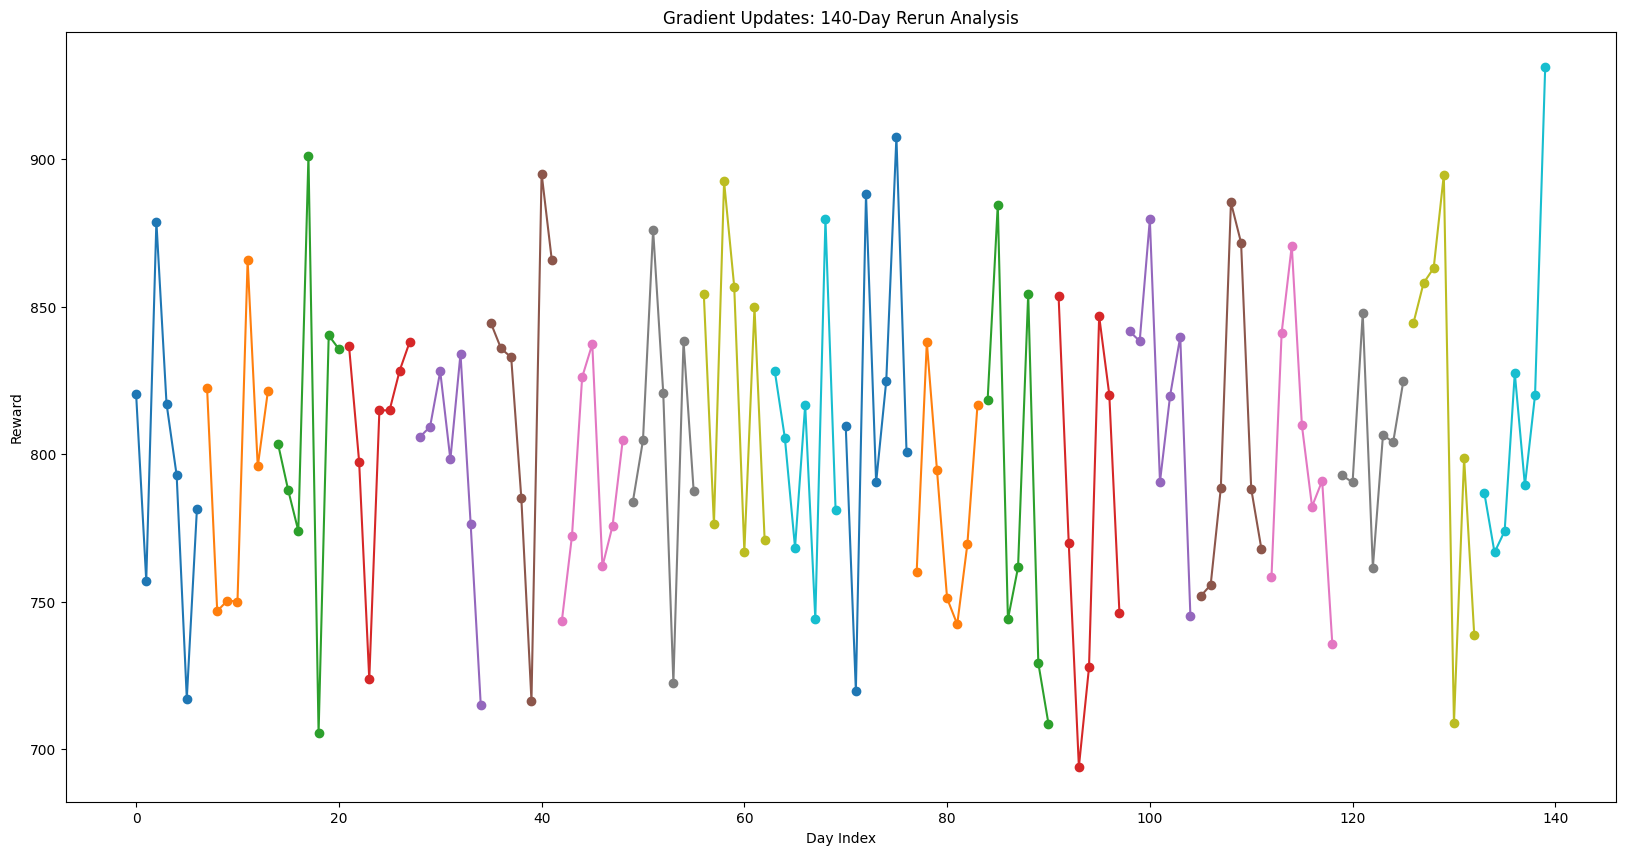

In [27]:
plt.figure(figsize=(20, 10))
plt.scatter(rewards_df['index'], rewards_df['rewards'], c=rewards_df['week_idx'], cmap='viridis', s=10)
for group, group_data in rewards_df.groupby('week_idx'):
    plt.plot(group_data['index'], group_data['rewards'], marker='o', linestyle='-', label=f'Group {group}')

plt.title("Gradient Updates: 140-Day Rerun Analysis")
plt.xlabel("Day Index")
plt.ylabel("Reward")
plt.show()

### train 20 weeks, each week we reset the simulation(i.e. thetas, lr and such is reset every week)

In [16]:
rewards_lst = []
max_reward = 0
l2_lambda = 0.01
lr = 0.001
lr_decay_factor = 0.95

grad_total_weeks = 20
days_in_a_batch = 7
simdata_folder = '../data/update_gradient/20_weeks/'

W = np.random.rand(3,2*days_in_a_batch-1)
#pricing_params = (5, 0.78, 1.82)

#print('W:', W)

for w in tqdm(range(grad_total_weeks)):
    learning_rate = lr * (lr_decay_factor ** w)
    print("------------------------------------------------------------------------------------------")
    print('learning_rate:', learning_rate)
    pricing_params = np.random.rand(3)
    simulation_this_week = WeeklySimulation(w, learning_rate, pricing_params, None, "")
    context_prev_rewards = np.zeros(days_in_a_batch-1)
    for d in range(days_in_a_batch):
        context_day_of_week = np.zeros(days_in_a_batch)
        context_day_of_week[d] = 1
        
        if d > 0:
            context_prev_rewards[d-1] = rewards_lst[-1] if rewards_lst[-1]>0 else 0
        
        print(f'week:%d, day:%d'%(w, d))

        context_vec = np.concatenate([context_day_of_week, context_prev_rewards])
        #print('context_vec:', context_vec)

        drivers_this_week_today = simulation_this_week.simulate_supply()
        requests_this_week_today = simulation_this_week.simulate_demand()
        print("simulation_this_week.daily_num_requests:", simulation_this_week.daily_num_requests.sum().int().item())

        simulation_this_week.request_driver_matching(verbose=0)
        simulation_this_week.update_gamma_distns()
        
        simdata_filename = 'exposed_prices_'+'week_'+str(w)+'_day_'+str(d)+'.json'
        with open(os.path.join(simdata_folder,simdata_filename), 'w') as json_file:
            json.dump(simulation_this_week.exposed_prices, json_file, indent=4)

        exposed_price_df = pd.read_json(os.path.join(simdata_folder, simdata_filename))
        print(f"num of exposed prices:%d, num of matched prices:%d"%(len(exposed_price_df), len(exposed_price_df[exposed_price_df.both_accepted==1])))

        todays_rewards = exposed_price_df[exposed_price_df.both_accepted==1]['price_of_ride'].sum() * simulation_this_week.charge_percentage
        
        if todays_rewards > max_reward:
            max_reward = todays_rewards
            print('current reward is the max reward so far')
            print('todays_rewards:', todays_rewards)
        
        rewards_lst.append(todays_rewards)

        exposed_price_df['ride_grad'] = simulation_this_week.charge_percentage*exposed_price_df.rider_acceptance_prob*exposed_price_df.driver_acceptance_prob* \
                        (1+exposed_price_df.distance_normalized_price*(\
                        (1-exposed_price_df.rider_acceptance_prob)*simulation_this_week.b_r)+(1-exposed_price_df.driver_acceptance_prob)*simulation_this_week.b_d)

        exposed_price_df['ride_gradient_theta1'] = exposed_price_df.ride_grad * 2 * exposed_price_df.trip_miles
        exposed_price_df['ride_gradient_theta2'] = exposed_price_df.ride_grad * exposed_price_df.trip_miles
        exposed_price_mean_df = exposed_price_df[['ride_grad', 'ride_gradient_theta1', 'ride_gradient_theta2']].mean()
        
        W[0] = W[0] + lr * (exposed_price_mean_df.ride_grad * context_vec + l2_lambda * W[0])
        W[1] = W[1] + lr * (exposed_price_mean_df.ride_gradient_theta1 * context_vec + l2_lambda * W[1])
        W[2] = W[2] + lr * (exposed_price_mean_df.ride_gradient_theta2 * context_vec + l2_lambda * W[2])

        pricing_params = np.matmul(W, context_vec)

        #print('W:', W)
        print('pricing_params:', pricing_params)

  0%|          | 0/20 [00:00<?, ?it/s]

------------------------------------------------------------------------------------------
learning_rate: 0.001
week:0, day:0
simulation_this_week.daily_num_requests: 890
num of exposed prices:709, num of matched prices:361
current reward is the max reward so far
todays_rewards: 1182.3858
pricing_params: [0.5859317  0.6082041  0.99895795]
week:0, day:1
simulation_this_week.daily_num_requests: 865
num of exposed prices:608, num of matched prices:303
pricing_params: [1148.04293483 2274.33056665 1654.04242731]
week:0, day:2
simulation_this_week.daily_num_requests: 872
num of exposed prices:687, num of matched prices:345
pricing_params: [1881.69092579 6402.70605399 3942.71861233]
week:0, day:3
simulation_this_week.daily_num_requests: 919
num of exposed prices:694, num of matched prices:340
current reward is the max reward so far
todays_rewards: 1193.9406
pricing_params: [ 2629.45856503 12402.76313491  6977.28500659]
week:0, day:4
simulation_this_week.daily_num_requests: 854
num of exposed 

  5%|▌         | 1/20 [00:00<00:18,  1.01it/s]

num of exposed prices:604, num of matched prices:301
pricing_params: [ 6626.14666969 39217.05779012 19562.97748688]
------------------------------------------------------------------------------------------
learning_rate: 0.00095
week:1, day:0
simulation_this_week.daily_num_requests: 883
num of exposed prices:633, num of matched prices:355
pricing_params: [0.58611139 0.60978582 0.99979745]
week:1, day:1
simulation_this_week.daily_num_requests: 848
num of exposed prices:585, num of matched prices:313
pricing_params: [1485.02534468 9108.12988562 4912.51828681]
week:1, day:2
simulation_this_week.daily_num_requests: 927
num of exposed prices:646, num of matched prices:347
pricing_params: [ 2446.07985219 16640.38738858  8846.04140163]
week:1, day:3
simulation_this_week.daily_num_requests: 886
num of exposed prices:654, num of matched prices:368
pricing_params: [ 3376.2741994  25095.33794113 13097.44219717]
week:1, day:4
simulation_this_week.daily_num_requests: 936
num of exposed prices:739,

 10%|█         | 2/20 [00:01<00:16,  1.07it/s]

...

num of exposed prices:666, num of matched prices:367
pricing_params: [ 26546.17412442 277906.93608072 139132.65060713]
week:17, day:6
simulation_this_week.daily_num_requests: 913
num of exposed prices:634, num of matched prices:367
pricing_params: [ 28494.48331368 294910.26254896 147487.02366612]
------------------------------------------------------------------------------------------
learning_rate: 0.0003972143184582182
week:18, day:0
simulation_this_week.daily_num_requests: 861
num of exposed prices:645, num of matched prices:313
pricing_params: [0.58910719 0.6356117  1.01353781]
week:18, day:1
simulation_this_week.daily_num_requests: 834
num of exposed prices:582, num of matched prices:329
pricing_params: [ 14897.91454905 154392.40249502  77665.34424062]
week:18, day:2
simulation_this_week.daily_num_requests: 892
num of exposed prices:653, num of matched prices:337
pricing_params: [ 27940.77763493 292949.83107069 147204.73043565]
week:18, day:3
simulation_this_week.daily_num_reques

 95%|█████████▌| 19/20 [00:17<00:00,  1.19it/s]

num of exposed prices:658, num of matched prices:325
pricing_params: [ 57915.72031511 600779.34220187 300306.57285294]
------------------------------------------------------------------------------------------
learning_rate: 0.00037735360253530727
week:19, day:0
simulation_this_week.daily_num_requests: 907
num of exposed prices:655, num of matched prices:388
pricing_params: [0.58929818 0.63732611 1.01444372]
week:19, day:1
simulation_this_week.daily_num_requests: 850
num of exposed prices:678, num of matched prices:373
pricing_params: [ 8516.49277286 88462.12389121 44486.10436098]
week:19, day:2
simulation_this_week.daily_num_requests: 924
num of exposed prices:654, num of matched prices:370
pricing_params: [ 15126.2436408  158824.87662547  79792.79754842]
week:19, day:3
simulation_this_week.daily_num_requests: 864
num of exposed prices:636, num of matched prices:390
pricing_params: [ 20318.32016611 214690.07244127 107741.67974591]
week:19, day:4
simulation_this_week.daily_num_requests

100%|██████████| 20/20 [00:18<00:00,  1.10it/s]

num of exposed prices:657, num of matched prices:386
pricing_params: [ 27497.44283952 289267.85002454 144760.0057447 ]
week:19, day:6
simulation_this_week.daily_num_requests: 875
num of exposed prices:585, num of matched prices:338
pricing_params: [ 29563.76152417 307712.81406964 153834.37647948]


In [17]:
rewards_df = pd.DataFrame({'rewards': rewards_lst}).reset_index()
rewards_df['week_idx'] = (rewards_df.index // 7)

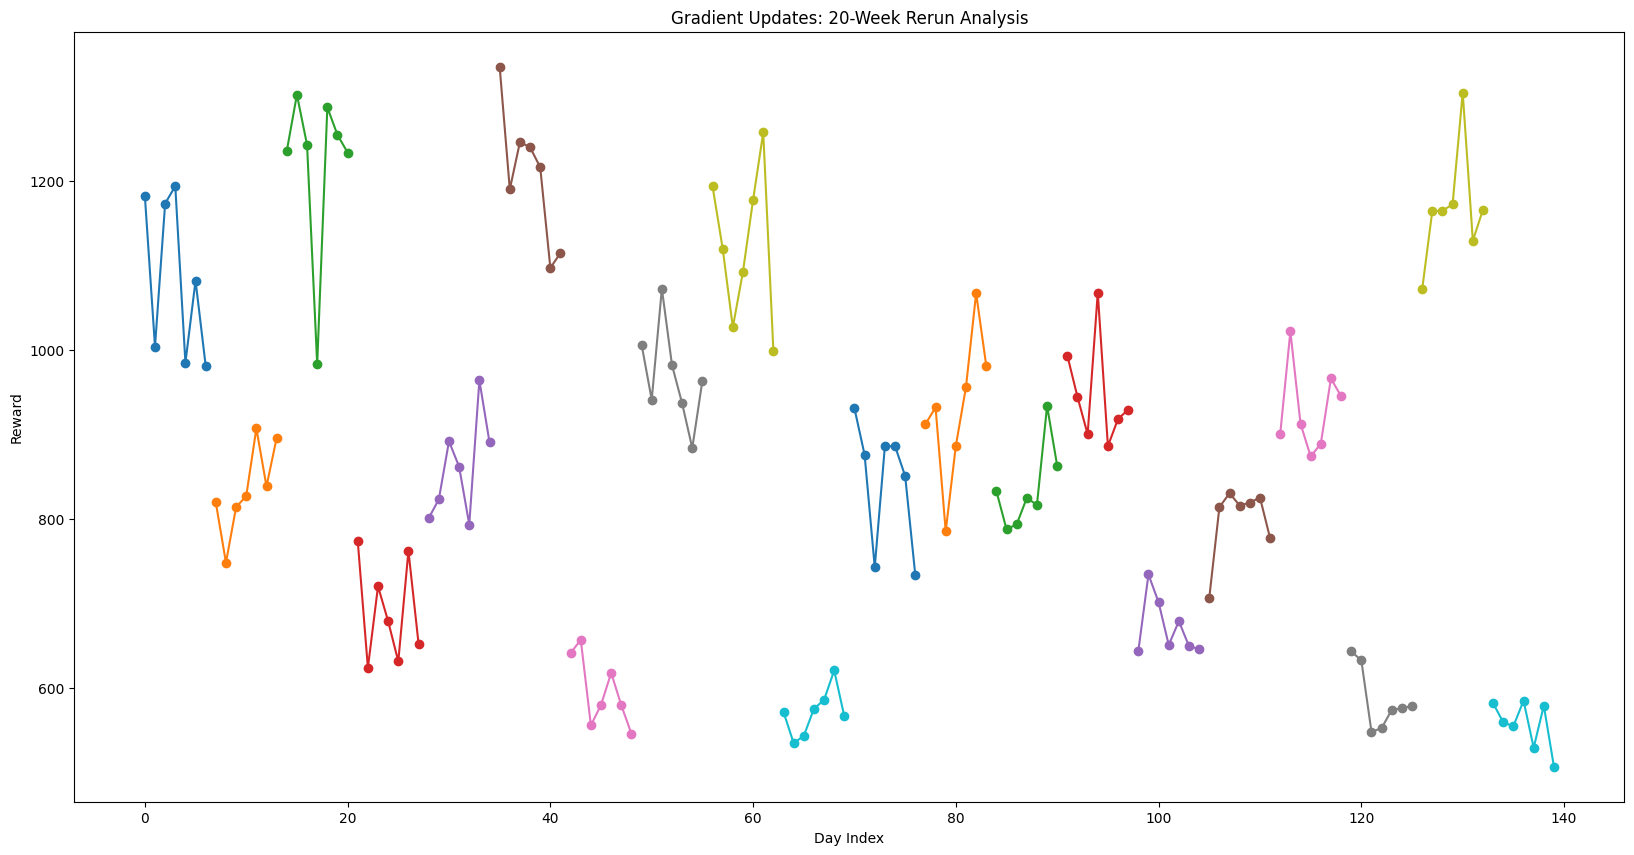

In [22]:
plt.figure(figsize=(20, 10))
plt.scatter(rewards_df['index'], rewards_df['rewards'], c=rewards_df['week_idx'], cmap='viridis', s=10)
for group, group_data in rewards_df.groupby('week_idx'):
    plt.plot(group_data['index'], group_data['rewards'], marker='o', linestyle='-', label=f'Group {group}')

plt.title("Gradient Updates: 20-Week Rerun Analysis")
plt.xlabel("Day Index")
plt.ylabel("Reward")
plt.show()